In [2]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

In [3]:
PATH = 'datasets/ISIC_2020_corrected'
os.listdir(PATH)

['multiclass',
 'subset.csv',
 'test_split.csv',
 'train',
 'train.csv',
 'train_resized',
 'train_sd_split.csv',
 'train_split.csv',
 'val_split.csv']

In [4]:
train = pd.read_csv(f'{PATH}/multiclass/train_split_multiclass.csv')
val = pd.read_csv(f'{PATH}/multiclass/val_split_multiclass.csv')
test = pd.read_csv(f'{PATH}/multiclass/test_multiclass.csv')
train.shape, val.shape

((4794, 9), (599, 9))

In [5]:
train.head()

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_1550721,IP_5623232,IL_6132060,female,50.0,torso,2,benign,0
1,ISIC_8180188,IP_5890334,IL_1640286,male,50.0,upper extremity,2,benign,0
2,ISIC_1259014,IP_5623232,IL_8572893,female,50.0,torso,2,benign,0
3,ISIC_5322232,IP_9806578,IL_3333972,male,70.0,lower extremity,2,benign,0
4,ISIC_4026806,IP_3562983,IL_8793536,male,35.0,torso,2,benign,0


In [6]:
NUM_CLASSES = len(train['diagnosis'].value_counts())
NUM_CLASSES

5

(array([  30.,    0.,  108.,    0.,    0., 4154.,    0.,  467.,    0.,
          35.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

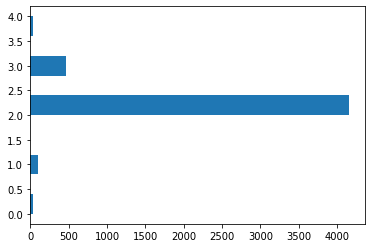

In [7]:
plt.hist(train['diagnosis'], orientation='horizontal')

In [8]:
train.diagnosis.value_counts()

2    4154
3     467
1     108
4      35
0      30
Name: diagnosis, dtype: int64

In [125]:
train.diagnosis.values

array([2, 2, 2, ..., 2, 2, 2], dtype=int64)

In [75]:
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["diagnosis"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds

In [76]:
train_ds = load_ds(train)
val_ds = load_ds(val)
test_ds = load_ds(test)

In [138]:
IMAGE_SIZE = (256, 256, 3)

encoder = ResNet50V2(
    include_top=False,
    input_shape=IMAGE_SIZE,
    weights='imagenet'
)
encoder.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE)
x = keras.layers.Rescaling(1./255)(inputs)
x = encoder(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(NUM_CLASSES, activation ='softmax')(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_52 (InputLayer)       [(None, 256, 256, 3)]     0         
                                                                 
 rescaling_25 (Rescaling)    (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d_25  (None, 2048)             0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_25 (Dense)            (None, 5)                 10245     
                                                                 
Total params: 23,575,045
Trainable params: 10,245
Non-trainable params: 23,564,800
_________________________________________

In [157]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics = keras.metrics.Precision(),
)

In [158]:
filepath = 'models/checkpoints/baseline2_multi'
cb = tf.keras.callbacks.ModelCheckpoint(
    filepath = filepath,
    monitor="val_auc",
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode="max"
)

In [159]:
history = model.fit(train_ds,
                    epochs=10,
                    validation_data=val_ds,
                    #validation_steps=10,
                    callbacks=[cb]
                   )

Epoch 1/10


ValueError: in user code:

    File "C:\Users\Usuario\Desktop\Pablo\TFG\PythonEnv\.venv\lib\site-packages\keras\engine\training.py", line 1021, in train_function  *
        return step_function(self, iterator)
    File "C:\Users\Usuario\Desktop\Pablo\TFG\PythonEnv\.venv\lib\site-packages\keras\engine\training.py", line 1010, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "C:\Users\Usuario\Desktop\Pablo\TFG\PythonEnv\.venv\lib\site-packages\keras\engine\training.py", line 1000, in run_step  **
        outputs = model.train_step(data)
    File "C:\Users\Usuario\Desktop\Pablo\TFG\PythonEnv\.venv\lib\site-packages\keras\engine\training.py", line 864, in train_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "C:\Users\Usuario\Desktop\Pablo\TFG\PythonEnv\.venv\lib\site-packages\keras\engine\training.py", line 957, in compute_metrics
        self.compiled_metrics.update_state(y, y_pred, sample_weight)
    Fil

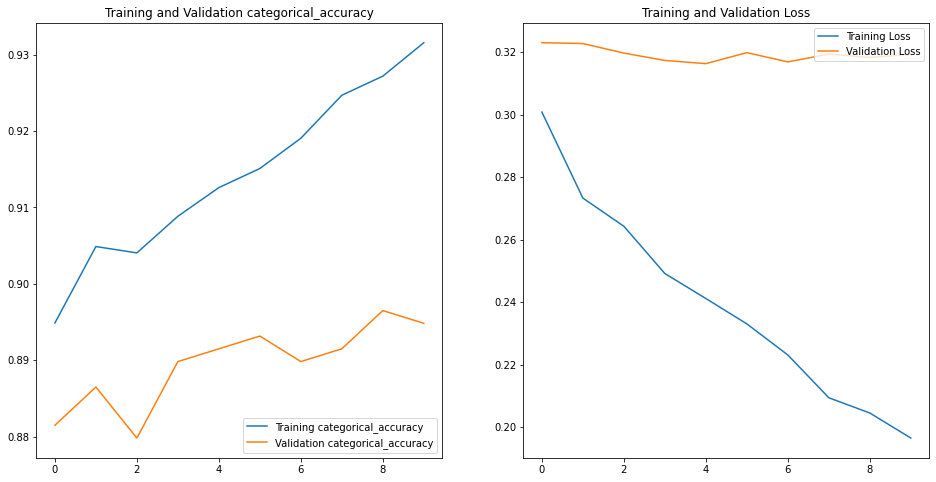

In [151]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training categorical_accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation categorical_accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation categorical_accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [152]:
results = model.evaluate(test_ds)
print(results)

10/10 [==============================] - 2s 189ms/step - loss: 0.3806 - accuracy: 0.8850
[0.3805654048919678, 0.8849999904632568]


In [153]:
predictions = model.predict(test_ds)

In [51]:
model.load_weights(filepath)
model.save('models/baseline2.h5')